# Gender pay gap at the bank

This notebook works through a classic question in applied statistics: is there a gender pay gap, and does it survive once we account for the things that legitimately drive salary such as education, job grade, and time at the bank?

We build a sequence of regression models, from the simplest possible baseline up to models with interaction terms. The point is not just to find the "best" model. It is to watch how the story changes as we add controls, and to think carefully about what each coefficient is actually telling us.

## Setting up

We start by loading the libraries we need. `pandas` handles the data, `numpy` gives us the maths, `matplotlib` and `seaborn` do the plotting, and `statsmodels` gives us regression with proper statistical output (coefficients, standard errors, p-values, and so on).

We also silence warnings and fix a few plotting defaults so every chart looks consistent.

In [57]:
# Importing libraries
import pandas as pd            # pandas for handling datasets
import numpy as np             # numpy for the maths
import matplotlib.pyplot as plt  # plotting
import seaborn as sns          # informative statistical plots
import statsmodels.api as sm             # statistical models
import statsmodels.formula.api as smf    # formula interface (salary ~ gender, etc.)
import warnings                # handling warnings

# Masking warnings so the output stays clean
warnings.filterwarnings('ignore')

# Setting the plots' layout
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'

## Loading the data and a first look

We read the salary data straight from a CSV file. Before modelling anything, it pays to look at what we have. `info()` tells us the columns, their types, and whether anything is missing. `describe()` gives us the numeric summaries: means, spreads, and ranges.

This first look is where you catch problems early, such as a column read in as text when it should be a number, or a range that looks implausible.

In [58]:
# Load the data
bank_salaries = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data/bank_salaries.csv")


# Summary statistics
print("Data summary:")
print(bank_salaries.info())
print("\nSummary statistics:")
print(bank_salaries.describe().T.round(2))

Data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   salary       208 non-null    int64 
 1   education    208 non-null    int64 
 2   job_grade    208 non-null    int64 
 3   years_bank   208 non-null    int64 
 4   years_prior  208 non-null    int64 
 5   age          208 non-null    int64 
 6   gender       208 non-null    object
 7   PC_job       208 non-null    object
dtypes: int64(6), object(2)
memory usage: 13.1+ KB
None

Summary statistics:
             count      mean       std      min      25%      50%       75%  \
salary       208.0  39921.92  11256.15  26700.0  33000.0  37000.0  44000.00   
education    208.0      3.16      1.47      1.0      2.0      3.0      5.00   
job_grade    208.0      2.75      1.56      1.0      1.0      3.0      4.00   
years_bank   208.0      9.67      6.99      2.0      5.0      8.0     13.00   


## Telling Python what is categorical

Education and job grade are stored as text, but they are really categories. Marking them as categorical lets `statsmodels` handle them correctly in the regressions later, turning each level into its own indicator.

We then break salary down by gender. This raw comparison is our starting hypothesis: on average, do men and women in this bank earn the same? Keep the numbers you see here in mind, because the whole exercise is about whether that raw gap holds up once we control for everything else.

In [59]:
# Convert categorical variables
bank_salaries['education'] = bank_salaries['education'].astype('category')
bank_salaries['job_grade'] = bank_salaries['job_grade'].astype('category')

# Salary summary statistics by gender
print("\nSalary summary statistics by gender:")
print(bank_salaries.groupby('gender')['salary'].describe().round(2))


Salary summary statistics by gender:
        count      mean       std      min      25%      50%      75%      max
gender                                                                        
Female  140.0  37209.93   6710.87  26800.0  32575.0  35450.0  41550.0  61800.0
Male     68.0  45505.44  15843.22  26700.0  34375.0  42500.0  48625.0  97000.0


## Two ways to check a model

A regression summary tells us about coefficients and fit, but it says nothing about whether the model's assumptions actually hold, or whether it predicts well. Two plots cover most of that ground, so we define them once here and call them on whichever models we want to scrutinise later. The same two functions also live in `model_diagnostics.py` beside this notebook, if you want to reuse them elsewhere.

The **four-panel diagnostics** are the same `check_model` view used elsewhere in the course. Residuals vs Fitted looks for leftover pattern the model missed. Normal Q-Q asks whether the residuals are roughly normal. Scale-Location checks whether their spread stays constant. Residuals vs Leverage flags individual employees with outsized influence on the fit.

The **actual vs predicted** plot is simpler to read. Each point is one employee, with their real salary across and the model's prediction up. The closer the cloud hugs the red 45 degree line, the better the model predicts. This is the salary version of the time series plot we use for the bikes data, where there is no date axis to plot against.

In [60]:
# Diagnostic plots for a fitted model (similar to R's check_model)
# Reused from session07_lecture3/03_wine.py
def plot_model_diagnostics(model):
    residuals = model.resid
    fitted_vals = model.fittedvalues

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Residuals vs Fitted
    sns.residplot(x=fitted_vals, y=residuals, lowess=True,
                  scatter_kws={'alpha': 0.5},
                  line_kws={'color': 'red', 'lw': 2}, ax=axes[0, 0])
    axes[0, 0].set_title('Residuals vs Fitted')
    axes[0, 0].set_xlabel('Fitted values')
    axes[0, 0].set_ylabel('Residuals')

    # Normal Q-Q
    sm.qqplot(residuals, line='s', ax=axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q')

    # Scale-Location
    sqrt_abs_resid = (abs(residuals))**0.5
    axes[1, 0].scatter(fitted_vals, sqrt_abs_resid, alpha=0.5)
    sns.regplot(x=fitted_vals, y=sqrt_abs_resid, scatter=False, lowess=True,
                line_kws={'color': 'red', 'lw': 2}, ax=axes[1, 0])
    axes[1, 0].set_title('Scale-Location')
    axes[1, 0].set_xlabel('Fitted values')
    axes[1, 0].set_ylabel('sqrt{Standardized Residuals}')

    # Residuals vs Leverage
    fig = sm.graphics.influence_plot(model, ax=axes[1, 1], criterion="cooks")
    axes[1, 1].set_title('Residuals vs Leverage')

    plt.tight_layout()
    plt.show()

In [61]:
def plot_actual_vs_predicted(model, model_name, dataframe):
    """
    Plot a model's predicted salaries against the actual salaries.

    Each point is one employee: actual salary on the x-axis, predicted
    salary on the y-axis. The red dashed line is where prediction equals
    reality, so the closer the points sit to it, the better the model.

    Args:
        model: a fitted statsmodels model object.
        model_name (str): a descriptive name used in the plot title.
        dataframe (pd.DataFrame): the data, containing a 'salary' column.
    """
    print(f"\n--- Generating plot for {model_name} ---")

    # Copy the data and add predictions so everything stays aligned
    df_plot = dataframe.copy()
    df_plot['predicted_salary'] = model.predict(dataframe)

    # White background, like ggplot's theme_bw()
    plt.figure(figsize=(8, 8), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')
    ax.grid(True, color='lightgray', linestyle='-', linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)  # grid behind the points

    # One point per employee
    sns.scatterplot(data=df_plot, x='salary', y='predicted_salary',
                    color='blue', alpha=0.4, label='Employees')

    # The 45-degree line: predicted equals actual, a perfect fit
    lims = [min(df_plot['salary'].min(), df_plot['predicted_salary'].min()),
            max(df_plot['salary'].max(), df_plot['predicted_salary'].max())]
    ax.plot(lims, lims, color='red', linestyle='--', linewidth=1.5,
            label='Perfect prediction')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # Show how much of the variation the model explains
    ax.text(0.05, 0.95, f"R-squared = {model.rsquared:.3f}",
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='lightgray'))

    # Black borders, like theme_bw()
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

    plt.title(f'Actual vs. Predicted Salary - {model_name}')
    plt.xlabel('Actual Salary')
    plt.ylabel('Predicted Salary')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Model 0: the mean as a baseline

Every regression story should start with the humblest model possible. Model 0 predicts the same salary for everyone: the overall mean. It has no explanatory variables at all.

Why bother? Because it gives us a benchmark. Its residual standard error tells us how far off we are, on average, if we simply guess the mean for every employee. Every model after this one has to earn its keep by beating that baseline.

In [62]:
# Model 0: Salary ~ 1, the mean
model0 = smf.ols('salary ~ 1', data=bank_salaries).fit()
print("\nModel 0: Salary ~ 1")
print(model0.summary2().tables[1].round(2))
print("R-squared:", model0.rsquared.round(4))
print("Adjusted R-squared:", model0.rsquared_adj.round(4))
print(f"Residual SE: {model0.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals).


Model 0: Salary ~ 1
              Coef.  Std.Err.      t  P>|t|    [0.025    0.975]
Intercept  39921.92    780.47  51.15    0.0  38383.23  41460.62
R-squared: 0.0
Adjusted R-squared: 0.0
Residual SE: 11256.154


## Model 1: salary on gender alone

Now we add a single predictor: gender. The coefficient on gender is the raw pay gap, the average difference in salary between the two groups with nothing else accounted for.

This is the number that often makes headlines. Notice how small the R-squared is: gender on its own explains very little of the variation in pay. That is our first clue that a simple comparison is missing most of the picture.

In [63]:
# Model 1: Salary ~ Gender
model1 = smf.ols('salary ~ gender', data=bank_salaries).fit()
print("\nModel 1: Salary ~ Gender")
print(model1.summary2().tables[1].round(2))
print("R-squared:", model1.rsquared.round(4))
print("Adjusted R-squared:", model1.rsquared_adj.round(4))
print(f"Residual SE: {model1.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals).


Model 1: Salary ~ Gender
                   Coef.  Std.Err.     t  P>|t|    [0.025    0.975]
Intercept       37209.93    894.53  41.6    0.0  35446.31  38973.54
gender[T.Male]   8295.51   1564.49   5.3    0.0   5211.04  11379.98
R-squared: 0.1201
Adjusted R-squared: 0.1158
Residual SE: 10584.260


## Model 2: adding the legitimate drivers of pay

Salaries are not set at random. Education, job grade, and years at the bank all matter, and all of them may differ between men and women. Model 2 puts them in alongside gender.

The key question is what happens to the gender coefficient. If the raw gap shrinks once we control for these factors, part of it was explained by differences in qualifications and seniority. If a gap remains, that is the portion left unexplained by the variables we have. Watch how the gender coefficient moves compared with Model 1.

In [64]:
# Model 2: Salary ~ Gender + Education + Job Grade + Years at Bank
model2 = smf.ols('salary ~ gender + education + job_grade + years_bank', data=bank_salaries).fit()
print("\nModel 2: Salary ~ Gender + Education + Job Grade + Years at Bank")
print(model2.summary2().tables[1].round(2))
print("R-squared:", model2.rsquared.round(4))
print("Adjusted R-squared:", model2.rsquared_adj.round(4))
print(f"Residual SE: {model2.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals).


Model 2: Salary ~ Gender + Education + Job Grade + Years at Bank
                   Coef.  Std.Err.      t  P>|t|    [0.025    0.975]
Intercept       27966.93   1463.97  19.10   0.00  25079.77  30854.09
gender[T.Male]   1810.89   1008.66   1.80   0.07   -178.34   3800.11
education[T.2]   -742.01   1407.50  -0.53   0.60  -3517.80   2033.78
education[T.3]    704.42   1342.42   0.52   0.60  -1943.01   3351.86
education[T.4]    171.97   2467.33   0.07   0.94  -4693.96   5037.89
education[T.5]   2646.67   1627.40   1.63   0.11   -562.79   5856.13
job_grade[T.2]   2222.38   1208.22   1.84   0.07   -160.41   4605.17
job_grade[T.3]   5578.01   1283.44   4.35   0.00   3046.87   8109.14
job_grade[T.4]   9068.03   1531.10   5.92   0.00   6048.49  12087.58
job_grade[T.5]  14157.59   1896.60   7.46   0.00  10417.23  17897.96
job_grade[T.6]  24608.51   2947.57   8.35   0.00  18795.48  30421.54
years_bank        472.44     87.16   5.42   0.00    300.56    644.33
R-squared: 0.7463
Adjusted R-squared:

## Model 3: does the reward for experience differ by gender?

So far we have assumed one extra year at the bank is worth the same to everyone. The interaction term `years_bank * gender` relaxes that assumption. It lets the slope on experience differ between men and women.

If the interaction is significant, the two groups are being rewarded for experience at different rates, and the pay gap widens or narrows as careers progress. This is often more revealing than a single fixed gap, because it speaks to how pay diverges over time.

In [65]:
# Model 3: Salary ~ Years at Bank * Gender (interaction)
model3 = smf.ols('salary ~ years_bank * gender', data=bank_salaries).fit()
print("\nModel 3: Salary ~ Years at Bank * Gender")
display(model3.summary2().tables[1].round(2))
print("R-squared:", model3.rsquared.round(4))
print("Adjusted R-squared:", model3.rsquared_adj.round(4))
print(f"Residual SE: {model3.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals).


Model 3: Salary ~ Years at Bank * Gender


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,34528.28,1137.97,30.34,0.00,32284.59,36771.97
gender[T.Male],-4098.25,1665.84,-2.46,0.01,-7382.73,-813.78
years_bank,279.96,102.46,2.73,0.01,77.96,481.97
years_bank:gender[T.Male],1247.80,136.68,9.13,0.00,978.32,1517.28


R-squared: 0.6386
Adjusted R-squared: 0.6333
Residual SE: 6816.298


## Models 4 and 5: combining controls and interaction

Models 4 and 5 bring the pieces together: the experience-by-gender interaction plus the other controls. They are variations on the same idea, and comparing them shows how sensitive our conclusions are to exactly which variables we include.

Small changes in specification can move coefficients around. Part of good modelling is checking that your main finding is robust rather than an artefact of one particular set of choices.

In [66]:
# Model 4: Salary ~ All variables
model4 = smf.ols('salary ~ years_bank * gender + education + job_grade', data=bank_salaries).fit()
print("\nModel 4: Salary ~ All variables")
display(model4.summary2().tables[1].round(2))
print("R-squared:", model4.rsquared.round(4))
print("Adjusted R-squared:", model4.rsquared_adj.round(4))
print(f"Residual SE: {model4.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals).


Model 4: Salary ~ All variables


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,31643.14,1327.06,23.84,0.00,29025.91,34260.37
gender[T.Male],-6113.37,1272.45,-4.80,0.00,-8622.91,-3603.83
education[T.2],-659.11,1205.99,-0.55,0.59,-3037.57,1719.35
education[T.3],474.03,1150.51,0.41,0.68,-1795.01,2743.06
education[T.4],573.42,2114.54,0.27,0.79,-3596.89,4743.73
education[T.5],1995.34,1396.47,1.43,0.15,-758.78,4749.46
job_grade[T.2],2239.96,1035.21,2.16,0.03,198.31,4281.61
job_grade[T.3],5535.43,1099.67,5.03,0.00,3366.66,7704.20
job_grade[T.4],9928.73,1315.76,7.55,0.00,7333.77,12523.68
job_grade[T.5],13304.59,1628.12,8.17,0.00,10093.61,16515.58


R-squared: 0.8147
Adjusted R-squared: 0.8033
Residual SE: 4992.196


### Diagnosing Model 4

Model 4 is one of our fuller specifications, so it is worth putting under the microscope. Check whether the residuals still hold a pattern the model has missed, whether any single employee is dragging the fit, and how tightly the predictions hug the 45 degree line.

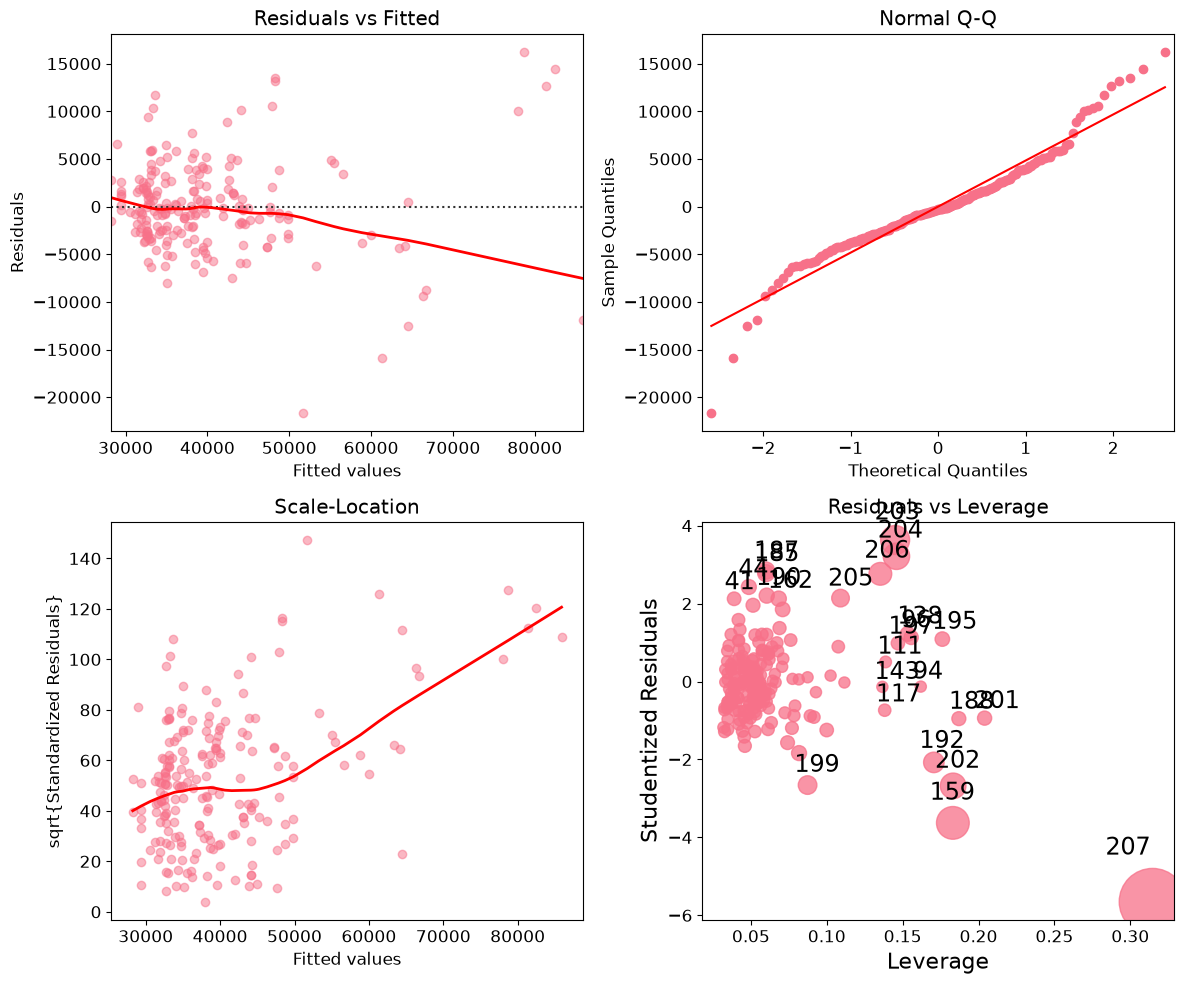

In [67]:
plot_model_diagnostics(model4)


--- Generating plot for Model 4: All Variables ---


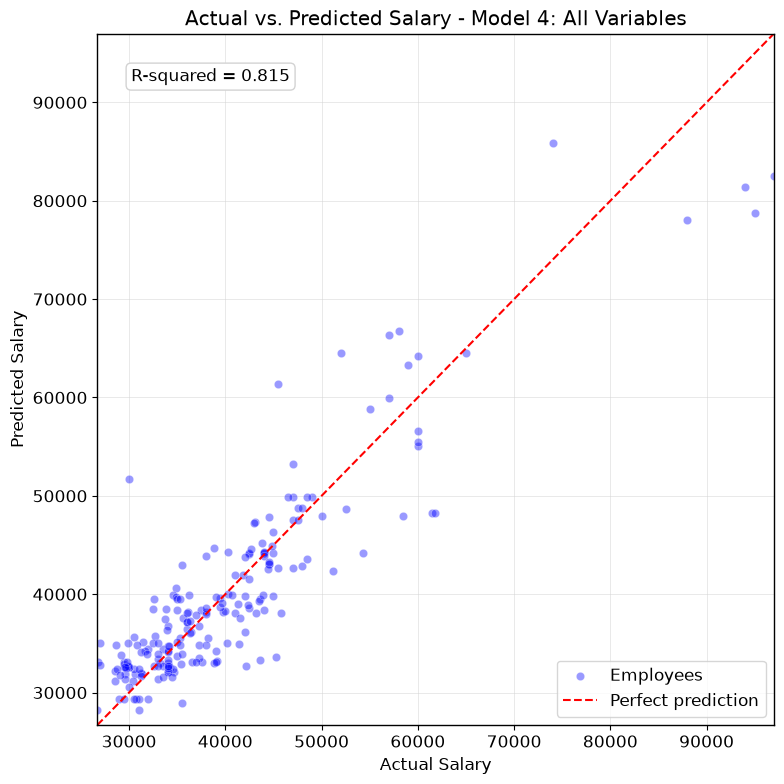

In [68]:
plot_actual_vs_predicted(model4, "Model 4: All Variables", bank_salaries)

In [69]:
# Model 5: Salary ~ Years at Bank * Gender + years_bank + Job Grade
from IPython.core.display_functions import display
model5 = smf.ols('salary ~ years_bank * gender + years_bank + job_grade', data=bank_salaries).fit()
print("\nModel 5: Salary ~ Years at Bank * Gender + years_bank + Job Grade")
display(model5.summary2().tables[1].round(2))
print("R-squared:", model5.rsquared.round(4))
print("Adjusted R-squared:", model5.rsquared_adj.round(4))
print(f"Residual SE: {model5.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals).


Model 5: Salary ~ Years at Bank * Gender + years_bank + Job Grade


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,32145.02,989.06,32.50,0.00,30194.64,34095.40
gender[T.Male],-6106.05,1271.27,-4.80,0.00,-8612.94,-3599.17
job_grade[T.2],2597.76,1011.26,2.57,0.01,603.60,4591.91
job_grade[T.3],6221.48,999.26,6.23,0.00,4250.98,8191.98
job_grade[T.4],11050.68,1173.90,9.41,0.00,8735.81,13365.55
job_grade[T.5],15061.14,1330.84,11.32,0.00,12436.78,17685.50
job_grade[T.6],16639.36,2491.68,6.68,0.00,11725.87,21552.85
years_bank,52.00,78.64,0.66,0.51,-103.08,207.07
years_bank:gender[T.Male],1035.00,119.49,8.66,0.00,799.36,1270.63


R-squared: 0.8105
Adjusted R-squared: 0.8029
Residual SE: 4997.053


## Putting the models side by side

Reading five separate summary tables is hard work. `summary_col` lines the models up in one table so we can compare coefficients and fit at a glance.

Read across a single row to see how a given effect, such as the gender coefficient, changes as we add controls. Read the bottom rows to compare R-squared and residual standard error. The stars flag statistical significance. This table is where the whole narrative comes together.

In [70]:
# Comparison of different models
from statsmodels.iolib.summary2 import summary_col

summary = summary_col([model1, model2, model3, model4, model5],
                      stars=True,
                      float_format='%0.3f',
                      model_names=['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5'],
                      info_dict={'Residual SE': lambda x: f"{x.scale ** 0.5:.3f}"})
display(summary)

,Model 1,Model 2,Model 3,Model 4,Model 5
Intercept,37209.929***,27966.931***,34528.280***,31643.141***,32145.021***
,(894.533),(1463.973),(1137.970),(1327.059),(989.060)
gender[T.Male],8295.513***,1810.886*,-4098.252**,-6113.366***,-6106.052***
,(1564.493),(1008.662),(1665.842),(1272.455),(1271.268)
education[T.2],,-742.009,,-659.110,
,,(1407.502),,(1205.991),
education[T.3],,704.425,,474.029,
,,(1342.418),,(1150.507),
education[T.4],,171.966,,573.420,
,,(2467.329),,(2114.543),


## Looking at where men and women actually sit

Regression coefficients can hide a structural story. If men and women are distributed differently across job grades, then "controlling for job grade" is doing a lot of quiet work, and it is worth seeing that distribution directly.

These cross-tabulations show how many people of each gender sit in each grade, and how salaries vary across grades. If one group is concentrated in the higher-paying grades, that is part of the mechanism behind any pay gap, not just noise to be controlled away.

In [71]:
# Count by gender and job grade
print("\nCount by gender and job grade:")
display(bank_salaries.groupby(['gender', 'job_grade']).size().unstack(fill_value=0))

# Salary statistics by job grade
print("\nSalary statistics by job grade:")
display(bank_salaries.groupby('job_grade')['salary'].describe())

# Gender distribution by job grade
print("\nGender distribution by job grade:")
display(bank_salaries.groupby('job_grade')['gender'].value_counts().unstack(fill_value=0))


# Gender distribution by job grade as percentages
gender_pct = (
    bank_salaries
    .groupby('job_grade')['gender']
    .value_counts()
    .unstack(fill_value=0)
    .apply(lambda row: row / row.sum() * 100, axis=1)
    .round(1)
)

# Optional: add "%" suffix for display
gender_pct_str = gender_pct.astype(str) + " %"

print("\nGender distribution by job grade (%):")
display(gender_pct_str)


Count by gender and job grade:


job_grade,1,2,3,4,5,6
gender,,,,,,
Female,48,29,36,17,9,1
Male,12,13,7,11,13,12



Salary statistics by job grade:


,count,mean,std,min,25%,50%,75%,max
job_grade,,,,,,,,
1,60.0,32335.166667,3944.347808,26700.0,29600.0,31100.0,34000.0,45300.0
2,42.0,34664.523810,3149.640477,28600.0,32560.0,34050.0,36875.0,42000.0
3,43.0,38664.651163,3584.790190,32500.0,36000.0,38000.0,41400.0,45800.0
4,28.0,44152.142857,3642.035814,35500.0,42500.0,44000.0,45125.0,54300.0
5,22.0,50768.181818,6058.711663,43000.0,47000.0,48250.0,56500.0,61800.0
6,13.0,68615.384615,19914.561095,30000.0,59000.0,60000.0,88000.0,97000.0



Gender distribution by job grade:


gender,Female,Male
job_grade,,
1,48,12
2,29,13
3,36,7
4,17,11
5,9,13
6,1,12



Gender distribution by job grade (%):


gender,Female,Male
job_grade,,
1,80.0 %,20.0 %
2,69.0 %,31.0 %
3,83.7 %,16.3 %
4,60.7 %,39.3 %
5,40.9 %,59.1 %
6,7.7 %,92.3 %


## Model 6: letting the grade effect differ by gender too

Model 6 adds a second interaction, `job_grade * gender`. This allows the pay premium for each grade to differ between men and women, not just the reward for experience.

This is the richest model in the notebook. It can capture the idea that the gap is not a single number but something that varies by seniority. The trade-off is complexity: more terms mean more coefficients to interpret and a greater risk of reading too much into a small sample.

In [72]:
# Model 6: Salary ~ Years at Bank * Gender + Job Grade * Gender
model6 = smf.ols('salary ~ years_bank * gender + job_grade * gender', data=bank_salaries).fit()
print("\nModel 6: Salary ~ Years at Bank * Gender + Job Grade * Gender")
display(model6.summary2().tables[1].round(2))
print("R-squared:", model6.rsquared.round(4))
print("Adjusted R-squared:", model6.rsquared_adj.round(4))
print(f"Residual SE: {model6.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals).


Model 6: Salary ~ Years at Bank * Gender + Job Grade * Gender


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,31239.94,984.60,31.73,0.00,29298.06,33181.83
gender[T.Male],-4753.62,1748.10,-2.72,0.01,-8201.34,-1305.89
job_grade[T.2],2397.59,1104.57,2.17,0.03,219.08,4576.11
job_grade[T.3],5936.91,1032.17,5.75,0.00,3901.20,7972.62
job_grade[T.4],11125.71,1352.90,8.22,0.00,8457.43,13793.98
job_grade[T.5],18019.79,1714.04,10.51,0.00,14639.25,21400.33
job_grade[T.6],-6347.97,5088.60,-1.25,0.21,-16384.05,3688.11
job_grade[T.2]:gender[T.Male],944.70,2175.00,0.43,0.66,-3344.98,5234.38
job_grade[T.3]:gender[T.Male],1932.64,2453.83,0.79,0.43,-2906.98,6772.25
job_grade[T.4]:gender[T.Male],-447.07,2387.60,-0.19,0.85,-5156.06,4261.92


R-squared: 0.838
Adjusted R-squared: 0.8271
Residual SE: 4680.014


### Diagnosing Model 6

Model 6 adds the grade by gender interaction, making it our richest model. Compare its diagnostics with Model 4. If the extra terms are earning their place, the residual patterns should be no worse and the predictions should sit at least as close to the line.

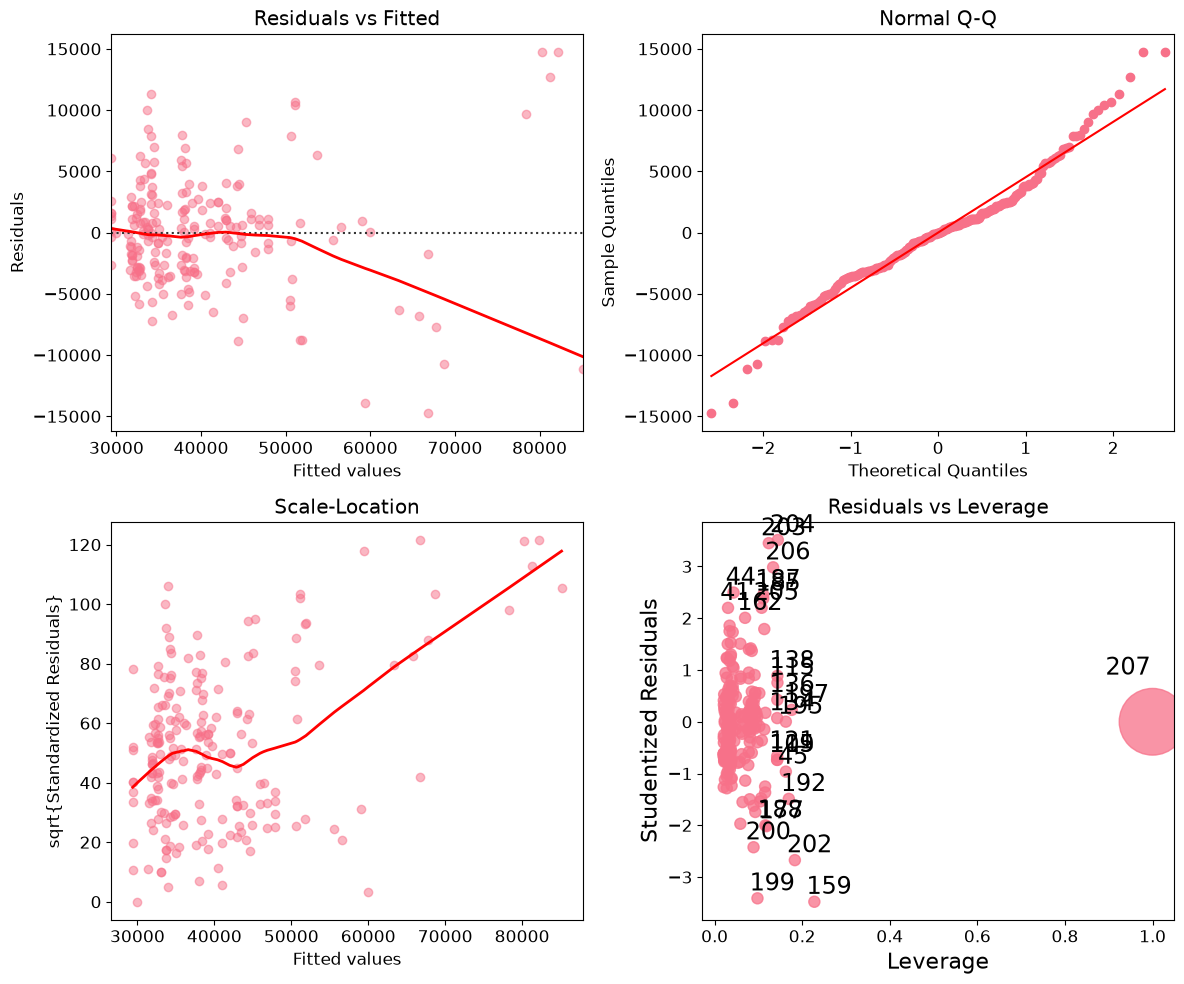

In [73]:
plot_model_diagnostics(model7)


--- Generating plot for Model 7: Years * Gender + Grade * Gender ---


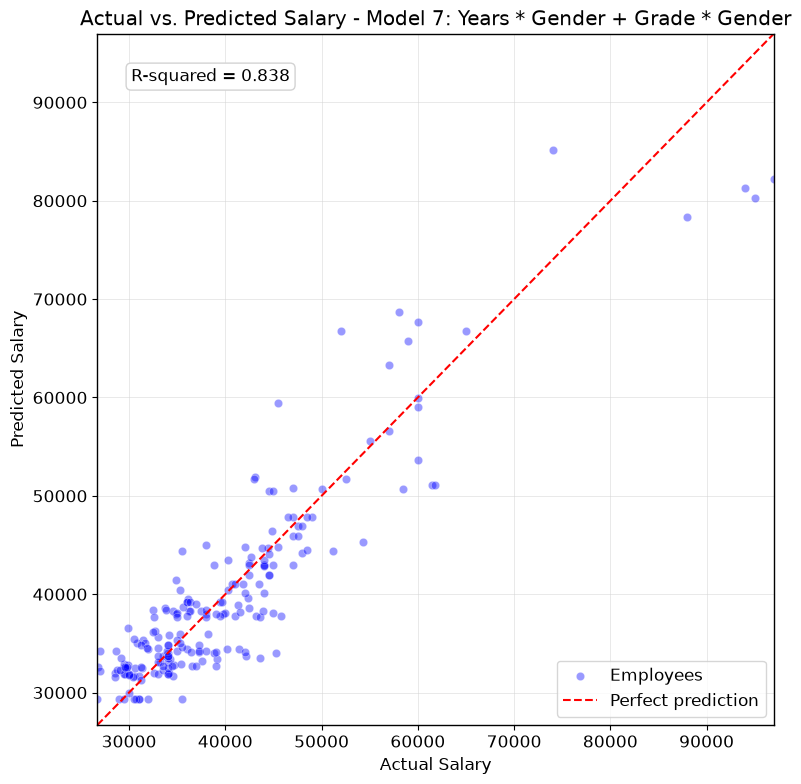

In [74]:
plot_actual_vs_predicted(model7, "Model 7: Years * Gender + Grade * Gender", bank_salaries)

## A tidy comparison of all the models

Finally we collect the fit statistics for every model into one small table: number of observations, R-squared, adjusted R-squared, and residual standard error.

Adjusted R-squared is the one to watch when comparing models with different numbers of predictors, because it penalises us for adding variables that do not pull their weight. A model that raises R-squared but lowers adjusted R-squared is probably overfitting.

In [75]:
# Model comparison
models = [model1, model2, model3, model4, model5, model6]
model_names = ['Years + Gender', 'Years + Gender + Education', 'Years * Gender', 'All Variables',
               'Years * Gender + Education + Grade', 'Years * Gender + Grade * Gender']

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Observations': [model.nobs for model in models],
    'R-squared': [model.rsquared for model in models],
    'Adj. R-squared': [model.rsquared_adj for model in models],
    'Residual SE': [np.sqrt(model.mse_resid) for model in models]
})

print("\nModel Comparison:")
display(comparison_df.round(4))


Model Comparison:


,Model,Observations,R-squared,Adj. R-squared,Residual SE
0,Years + Gender,208.0,0.1201,0.1158,10584.2605
1,Years + Gender + Education,208.0,0.7463,0.7321,5826.5435
2,Years * Gender,208.0,0.6386,0.6333,6816.2983
3,All Variables,208.0,0.8147,0.8033,4992.1957
4,Years * Gender + Education + Grade,208.0,0.8105,0.8029,4997.0532
5,Years * Gender + Grade * Gender,208.0,0.8380,0.8271,4680.0140


## Seeing it, not just reading it

Numbers tell you what happened; pictures tell you why. These three plots let us see the patterns the models are trying to capture.

The boxplots show how salary spreads within each job grade and how the genders compare inside each grade. The scatter with fitted lines shows salary against years at the bank, split by gender, and the gap between the two lines is exactly what the interaction term measures. If the lines are not parallel, the interaction was worth including.

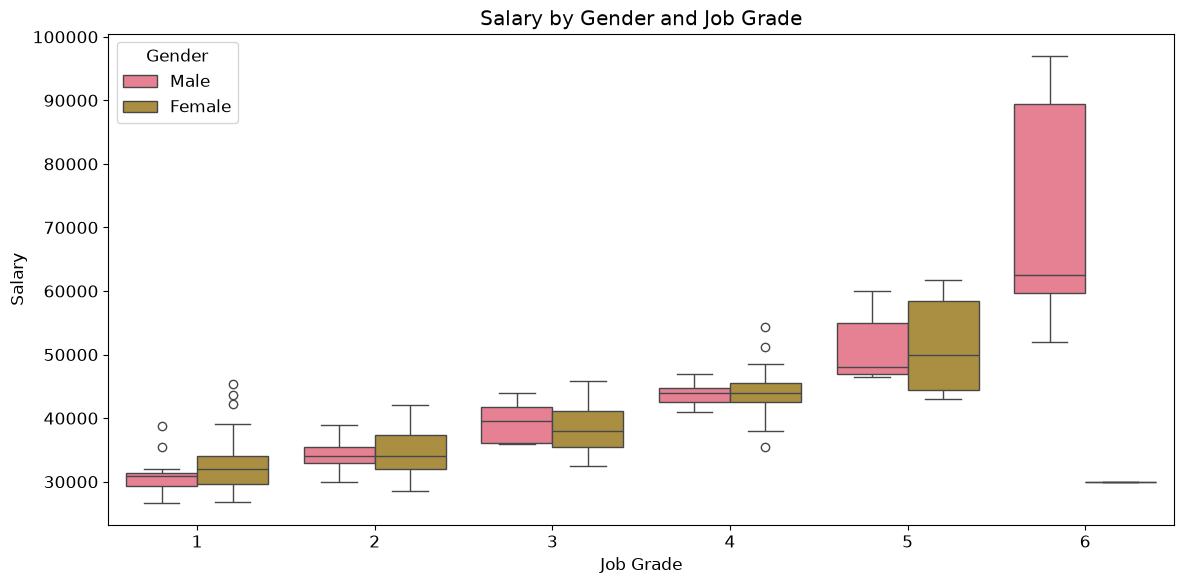

In [76]:
# Salary by gender and job grade
plt.figure(figsize=(12, 6))
sns.boxplot(data=bank_salaries, x='job_grade', y='salary', hue='gender')
plt.xlabel('Job Grade')
plt.ylabel('Salary')
plt.title('Salary by Gender and Job Grade')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

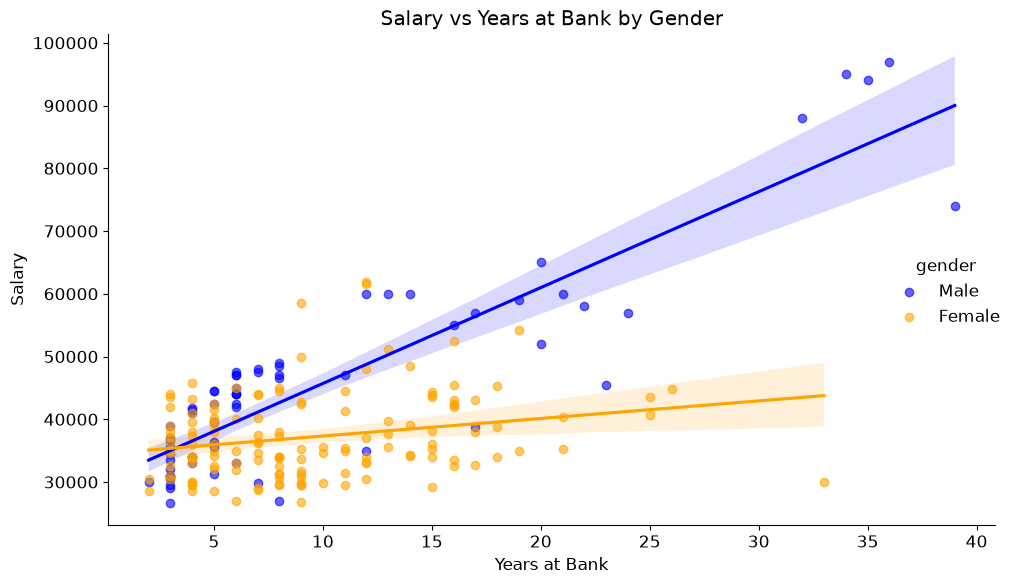

In [77]:
# Salary vs years at bank by gender - is an interaction needed in the regression?
plt.figure(figsize=(12, 10))
sns.lmplot(data=bank_salaries, x='years_bank', y='salary', hue='gender',
           palette={'Male': 'blue', 'Female': 'orange'}, height=6, aspect=1.5, scatter_kws={'alpha': 0.6})
plt.xlabel('Years at Bank')
plt.ylabel('Salary')
plt.title('Salary vs Years at Bank by Gender')
plt.tight_layout()
plt.show()

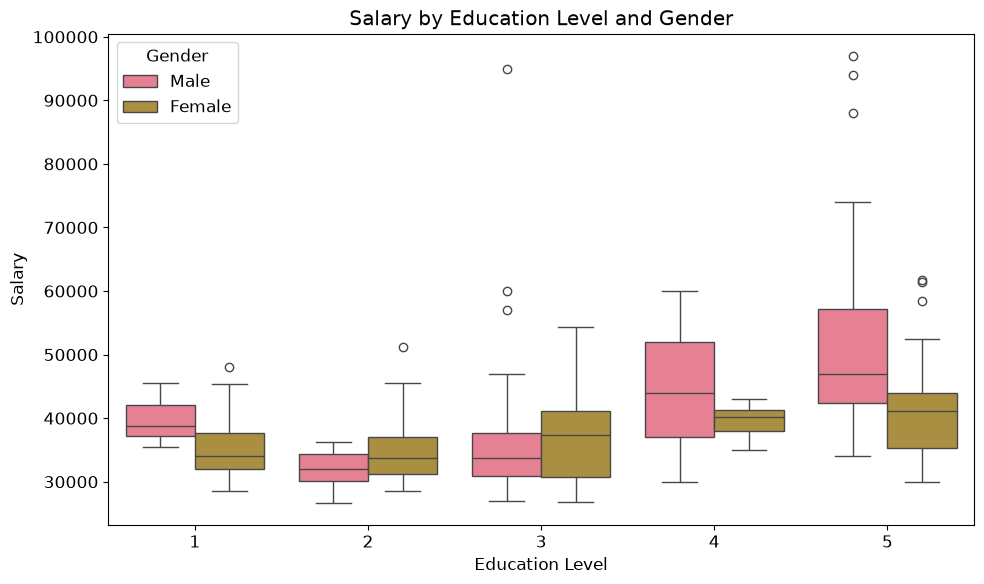

In [78]:
# Salary by education level
plt.figure(figsize=(10, 6))
sns.boxplot(data=bank_salaries, x='education', y='salary', hue='gender')
plt.xlabel('Education Level')
plt.ylabel('Salary')
plt.title('Salary by Education Level and Gender')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()